# Seasonal Agriculture Performance Analysis
### VOIS AICTE 2026–2027 Major Project
**Domain:** Data Analytics & Statistical Performance Evaluation  
**Dataset:** `seasonal_agriculture_performance_dataset.csv` (4,000 observations, 28 columns)  
---


## Section 1 — Data Loading and Cleaning
In this section, we import libraries, load the original dataset, inspect its shape, view sample records, audit missing values and duplicates, and apply justified median imputation to handle missing numerical entries.


In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np

# Load dataset
csv_file = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(csv_file)

# Inspect dataset shape and duplicates
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Display first 5 records (selected key columns)
print("\n--- First 5 Records ---")
sample_cols = ["Farm_ID", "State", "Crop", "Season", "Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha", "Profit_INR"]
print(df[sample_cols].head().to_string(index=False))

# Check missing values before cleaning
print("\n--- Missing Values (Before Cleaning) ---")
missing_before = df.isnull().sum()[df.isnull().sum() > 0]
for col, count in missing_before.items():
    print(f"{col:<20}: {count} missing ({count / len(df) * 100:.2f}%)")

# Apply median imputation for the three columns with missing values
impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
for col in impute_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Imputed '{col}' with median = {median_val:.2f}")

# Check missing values after cleaning
print(f"\n--- Total Missing Values (After Cleaning): {df.isnull().sum().sum()} ---")
print("Data cleaning complete: Zero missing values, zero duplicates, clean data ready.")


Dataset Shape: 4000 rows, 28 columns
Duplicate Rows: 0
--- First 5 Records ---
Farm_ID          State   Crop Season  Rainfall_mm  Soil_Moisture_pct  Yield_Tonnes_Ha  Profit_INR
SF10001 Andhra Pradesh  Wheat Kharif        486.4               32.8             2.46      -11852
SF10002    Maharashtra  Maize Kharif        855.4               32.0             0.30     -451950
SF10003      Telangana Pulses   Rabi        455.6                8.1             0.52     -124744
SF10004      Telangana   Rice Kharif        753.2               23.7             1.84      -95704
SF10005      Karnataka  Maize   Zaid        101.6               29.3             2.21     -144352
--- Missing Values (Before Cleaning) ---
Rainfall_mm         : 48 missing (1.20%)
Soil_Moisture_pct   : 40 missing (1.00%)
Yield_Tonnes_Ha     : 32 missing (0.80%)
Imputed 'Rainfall_mm' with median = 582.00
Imputed 'Soil_Moisture_pct' with median = 26.40
Imputed 'Yield_Tonnes_Ha' with median = 1.74
--- Total Missing Values (After C

## Section 2 — Seasonal Performance Analysis
In this section, we evaluate agricultural and economic performance across the three seasons: **Kharif**, **Rabi**, and **Zaid**. We compute mean yield, production, revenue, total cost, and net profit, followed by seasonal visualizations.


--- Seasonal Agricultural & Economic Performance ---
        Mean Yield (t/ha)  Mean Production (t)  Mean Revenue (INR)  Mean Total Cost (INR)  Mean Profit (INR)
Season                                                                                                      
Kharif               5.63                46.31           710719.06              531804.41          178914.65
Rabi                 5.04                41.49           601526.05              513836.58           87689.47
Zaid                 4.64                38.89           519171.90              543976.73          -24804.82


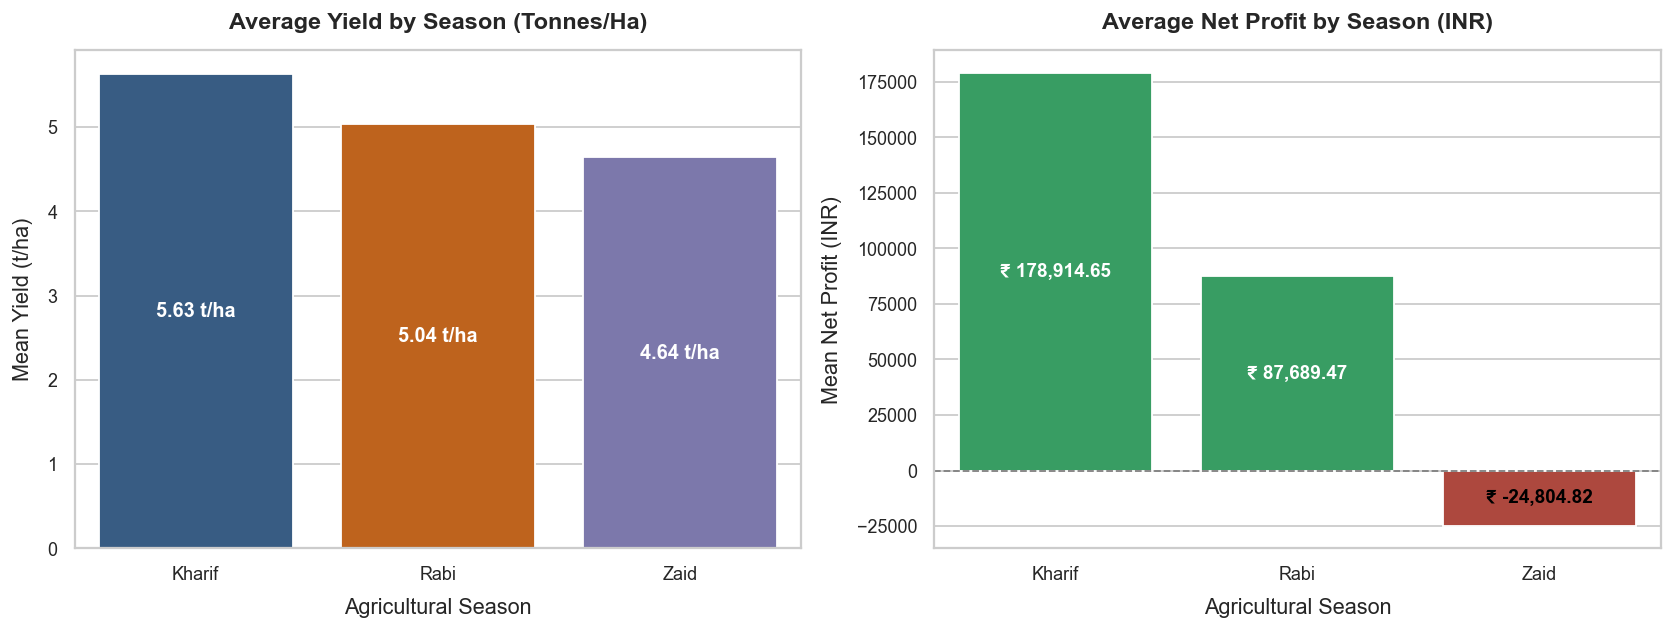

In [2]:
# Seasonal performance summary table
import matplotlib.pyplot as plt
import seaborn as sns

season_order = ["Kharif", "Rabi", "Zaid"]
metrics_map = {
    "Yield_Tonnes_Ha": "Mean Yield (t/ha)",
    "Production_Tonnes": "Mean Production (t)",
    "Revenue_INR": "Mean Revenue (INR)",
    "Total_Cost_INR": "Mean Total Cost (INR)",
    "Profit_INR": "Mean Profit (INR)"
}

seasonal_summary = df.groupby("Season")[list(metrics_map.keys())].mean().reindex(season_order)
seasonal_summary.columns = [metrics_map[c] for c in seasonal_summary.columns]
print("--- Seasonal Agricultural & Economic Performance ---")
print(seasonal_summary.round(2).to_string())

# Seasonal performance visualizations (Yield and Profit)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Average Yield by Season
yield_means = df.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(season_order)
sns.barplot(x=season_order, y=yield_means.values, palette=["#2b5c8f", "#d95f02", "#7570b3"], ax=axes[0])
axes[0].set_title("Average Yield by Season (Tonnes/Ha)", pad=12, fontweight="bold")
axes[0].set_xlabel("Agricultural Season", labelpad=8)
axes[0].set_ylabel("Mean Yield (t/ha)", labelpad=8)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f} t/ha", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold", fontsize=11)

# Chart 2: Average Net Profit by Season
profit_means = df.groupby("Season")["Profit_INR"].mean().reindex(season_order)
profit_colors = ["#27ae60" if v >= 0 else "#c0392b" for v in profit_means.values]
sns.barplot(x=season_order, y=profit_means.values, palette=profit_colors, ax=axes[1])
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Average Net Profit by Season (INR)", pad=12, fontweight="bold")
axes[1].set_xlabel("Agricultural Season", labelpad=8)
axes[1].set_ylabel("Mean Net Profit (INR)", labelpad=8)
for p in axes[1].patches:
    val = p.get_height()
    axes[1].annotate(f"₹ {val:,.2f}", (p.get_x() + p.get_width() / 2., val / 2),
                     ha="center", va="center", color="white" if abs(val) > 30000 else "black", fontweight="bold", fontsize=10.5)

plt.tight_layout()
plt.savefig("plots/01_average_yield_by_season.png", dpi=300)
plt.savefig("plots/02_average_profit_by_season.png", dpi=300)
plt.show()


## Section 3 — Crop and Irrigation Analysis
In this section, we examine crop-level productivity across seasons (Crop × Season average yield matrix) and compare the effectiveness of different irrigation regimes in terms of yield, profit, water consumption, and water productivity.


In [3]:
# Crop × Season analysis (Mean Yield in Tonnes/Ha)
crop_season_matrix = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].mean().unstack()[season_order]
print("--- Crop × Season Average Yield Matrix (Tonnes/Ha) ---")
print(crop_season_matrix.round(2).to_string())

# Irrigation analysis
irrig_order = ["Drip", "Sprinkler", "Flood", "Rainfed"]
irrig_metrics_map = {
    "Yield_Tonnes_Ha": "Mean Yield (t/ha)",
    "Profit_INR": "Mean Profit (INR)",
    "Water_Used_m3": "Mean Water Used (m³)",
    "Water_Efficiency_t_per_1000m3": "Mean Water Efficiency (t/1000m³)"
}

irrig_summary = df.groupby("Irrigation_Method")[list(irrig_metrics_map.keys())].mean().reindex(irrig_order)
irrig_summary.columns = [irrig_metrics_map[c] for c in irrig_summary.columns]
print("\n--- Irrigation Method Performance Summary ---")
print(irrig_summary.round(2).to_string())


--- Crop × Season Average Yield Matrix (Tonnes/Ha) ---
Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.47   1.20
Cotton       1.37   1.20   0.96
Groundnut    1.48   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.67
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.29  38.42
Wheat        2.25   2.06   1.75
--- Irrigation Method Performance Summary ---
                   Mean Yield (t/ha)  Mean Profit (INR)  Mean Water Used (m³)  Mean Water Efficiency (t/1000m³)
Irrigation_Method                                                                                              
Drip                            6.58          219626.00               5918.75                              6.27
Sprinkler                       5.16           91121.08               6208.26                              4.67
Flood                           4.86           73354.02               8026.47                              3.44
Rainfed            

## Section 4 — Correlation and ANOVA Analysis
In this section, we calculate Pearson correlations between agricultural yield and ambient environmental variables, followed by formal One-Way ANOVA tests to determine whether seasonal variations in yield and profit are statistically significant.


In [4]:
from scipy import stats

# Correlation analysis: Environmental variables vs Yield_Tonnes_Ha
env_features = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day", "Soil_Moisture_pct"]
print("--- Pearson Correlation Analysis with Yield_Tonnes_Ha ---")
print(f"{'Environmental Variable':<22} {'Pearson r':<12} {'p-value':<12} {'Significance (alpha=0.05)'}")
print("-" * 65)
for feat in env_features:
    r, p = stats.pearsonr(df[feat], df["Yield_Tonnes_Ha"])
    sig_status = "Significant" if p < 0.05 else "Not Significant"
    print(f"{feat:<22} {r:+.4f}      {p:.4f}      {sig_status}")

# One-Way ANOVA: Agricultural Yield Across Seasons
yield_groups = [group["Yield_Tonnes_Ha"].values for _, group in df.groupby("Season")]
f_yield, p_yield = stats.f_oneway(*yield_groups)
print("\n--- One-Way ANOVA: Yield Across Seasons ---")
print(f"Null Hypothesis (H0):         Mean yield is equal across Kharif, Rabi, and Zaid")
print(f"F-Statistic:                  {f_yield:.4f}")
print(f"p-value:                      {p_yield:.4f}")
conclusion_yield = "Reject H0 (Statistically Significant)" if p_yield < 0.05 else "Fail to reject H0 (Not Statistically Significant at alpha=0.05)"
print(f"Conclusion:                   {conclusion_yield}")

# One-Way ANOVA: Net Profit Across Seasons
profit_groups = [group["Profit_INR"].values for _, group in df.groupby("Season")]
f_profit, p_profit = stats.f_oneway(*profit_groups)
print("\n--- One-Way ANOVA: Net Profit Across Seasons ---")
print(f"Null Hypothesis (H0):         Mean net profit is equal across Kharif, Rabi, and Zaid")
print(f"F-Statistic:                  {f_profit:.4f}")
print(f"p-value:                      {p_profit:.4e}")
conclusion_profit = "Reject H0 (Statistically Significant, p < 0.001)" if p_profit < 0.05 else "Fail to reject H0"
print(f"Conclusion:                   {conclusion_profit}")


--- Pearson Correlation Analysis with Yield_Tonnes_Ha ---
Environmental Variable Pearson r    p-value      Significance (alpha=0.05)
-----------------------------------------------------------------
Rainfall_mm            +0.0310      0.0503      Not Significant
Avg_Temperature_C      +0.0100      0.5274      Not Significant
Humidity_pct           +0.0123      0.4368      Not Significant
Sunlight_Hours_Day     -0.0153      0.3320      Not Significant
Soil_Moisture_pct      +0.0110      0.4868      Not Significant
--- One-Way ANOVA: Yield Across Seasons ---
Null Hypothesis (H0):         Mean yield is equal across Kharif, Rabi, and Zaid
F-Statistic:                  1.5439
p-value:                      0.2137
Conclusion:                   Fail to reject H0 (Not Statistically Significant at alpha=0.05)
--- One-Way ANOVA: Net Profit Across Seasons ---
Null Hypothesis (H0):         Mean net profit is equal across Kharif, Rabi, and Zaid
F-Statistic:                  34.2918
p-value:         

## Section 5 — Key Findings & Recommendations

### Verified Key Findings
1. **Kharif Productivity & Profitability:** Kharif recorded the highest mean yield (**5.63 t/ha**), production (**46.31 t**), and profit (**₹178,914.65**).
2. **Zaid Deficit:** Zaid recorded lower mean yield (**4.64 t/ha**) and an average net loss (**-₹24,804.82**) due to high operating costs (₹543,976.73).
3. **Irrigation Performance:** Drip irrigation recorded the highest mean yield (**6.58 t/ha**), highest mean profit (**₹219,626.00**), and highest managed water efficiency (**6.27 t/1,000m³**). Flood irrigation recorded the lowest profit (**₹73,354.02**) and lowest efficiency (**3.44 t/1,000m³**).
4. **Crop Leaders:** Sugarcane led in overall biomass yield (Kharif: **53.46 t/ha**). Maize led cereal crops across all seasons (Kharif: **2.97 t/ha**, Rabi: **2.60 t/ha**, Zaid: **2.29 t/ha**).
5. **Weak Environmental Correlation:** Rainfall had the largest correlation with yield ($r = +0.0310$), but it is **weak and statistically insignificant** ($p = 0.0503 > 0.05$). Climatic metrics alone are not strong linear predictors of yield.
6. **ANOVA Inference:** Seasonal net profit differences are **highly statistically significant** ($F = 34.2918, p = 1.71 \times 10^{-15}$), whereas overall pooled seasonal yield differences did not reach statistical significance ($F = 1.5439, p = 0.2137$).

### Data-Driven Recommendations for Farm Management
1. **Capitalize on Kharif Cropping:** Focus primary investments in Kharif to maximize annual farm income.
2. **Restructure Zaid Farm Operations:** Transition away from high-cost summer flood farming toward drought-tolerant pulses or evaluate seasonal fallowing.
3. **Transition to Drip Irrigation:** Modernize flood systems to Drip irrigation to capture higher observed yields (+35.2%) and substantially higher profits.
4. **Schedule Preventive IPM in Kharif:** Deploy early pest monitoring ahead of peak monsoon humidity (71.81%) to mitigate elevated disease/pest risk (54.47%).
5. **Phase Out Flood Irrigation:** Deprecate flood irrigation to curtail water waste (8,026.47 m³ mean usage) and improve regional water sustainability.
